In [388]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [389]:
!git clone https://github.com/MakSi27/Customer-Lifetime-Value-Predictor.git

df = pd.read_csv("/content/Customer-Lifetime-Value-Predictor/data/processed/customer_details_processed.csv")

fatal: destination path 'Customer-Lifetime-Value-Predictor' already exists and is not an empty directory.


In [390]:
print(df)

           Age  Purchase Amount (USD)  Size  Review Rating  \
0     0.718913              -0.285629     3      -0.907584   
1    -1.648629               0.178852     3      -0.907584   
2     0.390088               0.558882     1      -0.907584   
3    -1.517099               1.276716     2      -0.349027   
4     0.061263              -0.454531     2      -1.466141   
...        ...                    ...   ...            ...   
3895 -0.267563              -1.341267     3       0.628448   
3896  0.521618              -0.454531     3       1.047366   
3897  0.127028              -1.130139     3      -1.186862   
3898 -0.004502               0.727784     1       0.069891   
3899  0.521618               0.896686     2      -0.907584   

      Subscription Status  Discount Applied  Promo Code Used  \
0                       1                 1                1   
1                       1                 1                1   
2                       1                 1                1   

In [391]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          3900 non-null   float64
 1   Purchase Amount (USD)        3900 non-null   float64
 2   Size                         3900 non-null   int64  
 3   Review Rating                3900 non-null   float64
 4   Subscription Status          3900 non-null   int64  
 5   Discount Applied             3900 non-null   int64  
 6   Promo Code Used              3900 non-null   int64  
 7   Previous Purchases           3900 non-null   float64
 8   Frequency of Purchases       3900 non-null   int64  
 9   Gender_Male                  3900 non-null   bool   
 10  Category_Clothing            3900 non-null   bool   
 11  Category_Footwear            3900 non-null   bool   
 12  Category_Outerwear           3900 non-null   bool   
 13  Season_Spring     

In [392]:
print(df.shape)

(3900, 26)


In [393]:
print(df.describe())

                Age  Purchase Amount (USD)         Size  Review Rating  \
count  3.900000e+03           3.900000e+03  3900.000000   3.900000e+03   
mean  -1.926664e-16          -1.220676e-16     2.320000   4.313359e-16   
std    1.000128e+00           1.000128e+00     0.881929   1.000128e+00   
min   -1.714394e+00          -1.679071e+00     1.000000  -1.745419e+00   
25%   -8.594483e-01          -8.767861e-01     2.000000  -9.075836e-01   
50%   -4.502378e-03           9.950067e-03     2.000000  -6.974802e-02   
75%    8.504436e-01           8.966862e-01     3.000000   9.077268e-01   
max    1.705390e+00           1.698971e+00     4.000000   1.745562e+00   

       Subscription Status  Discount Applied  Promo Code Used  \
count          3900.000000       3900.000000      3900.000000   
mean              0.270000          0.430000         0.430000   
std               0.444016          0.495139         0.495139   
min               0.000000          0.000000         0.000000   
25%     

In [394]:
print("Unique values in each column:")
for col in df.columns:
    print(col, ":", df[col].nunique())

Unique values in each column:
Age : 53
Purchase Amount (USD) : 81
Size : 4
Review Rating : 26
Subscription Status : 2
Discount Applied : 2
Promo Code Used : 2
Previous Purchases : 50
Frequency of Purchases : 5
Gender_Male : 2
Category_Clothing : 2
Category_Footwear : 2
Category_Outerwear : 2
Season_Spring : 2
Season_Summer : 2
Season_Winter : 2
Shipping Type_Express : 2
Shipping Type_Free Shipping : 2
Shipping Type_Next Day Air : 2
Shipping Type_Standard : 2
Shipping Type_Store Pickup : 2
Payment Method_Cash : 2
Payment Method_Credit Card : 2
Payment Method_Debit Card : 2
Payment Method_PayPal : 2
Payment Method_Venmo : 2


# RFM

In [395]:
df['recency'] = 1 / (df['Frequency of Purchases'] + 1)
df['frequency'] = df['Frequency of Purchases']
df['monetary'] = df['Purchase Amount (USD)']

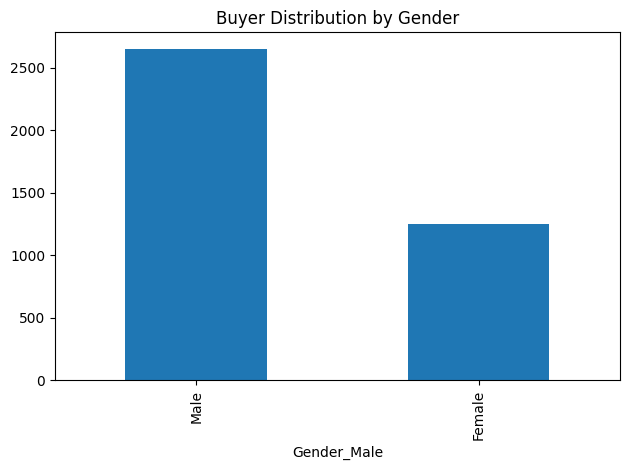

In [396]:
df['Gender_Male'].map({True:'Male', False:'Female'}).value_counts().plot(kind='bar')

plt.title('Buyer Distribution by Gender')
plt.tight_layout()
plt.show()

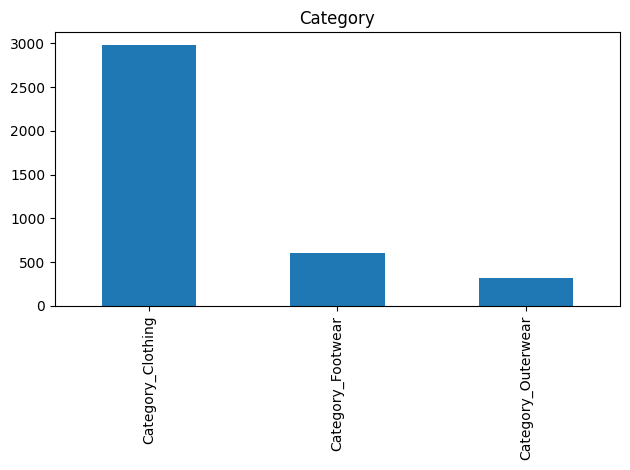

In [397]:
df[['Category_Clothing','Category_Footwear','Category_Outerwear']].idxmax(axis=1).value_counts().plot(kind='bar')

plt.title('Category')
plt.tight_layout()
plt.show()

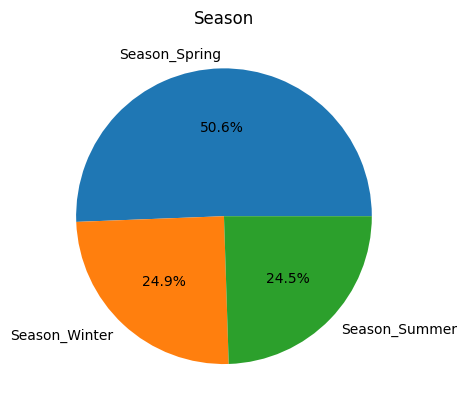

In [398]:

df[['Season_Spring','Season_Summer','Season_Winter']].idxmax(axis=1).value_counts().plot(kind = 'pie',  autopct='%1.1f%%')
plt.ylabel('')
plt.title('Season')
plt.show()



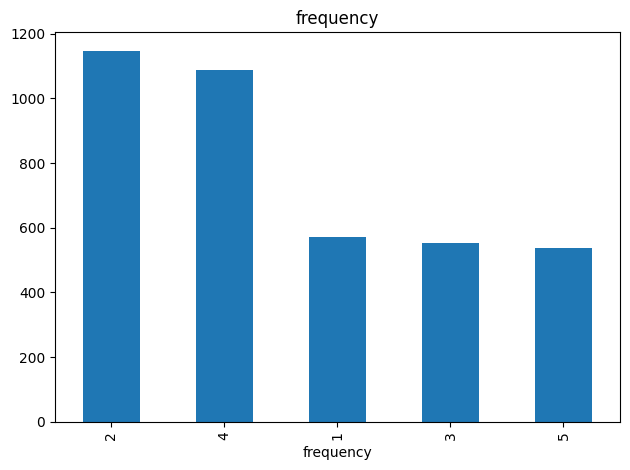

In [399]:
df['frequency'].value_counts().plot(kind='bar')
plt.title('frequency')
plt.tight_layout()
plt.show()

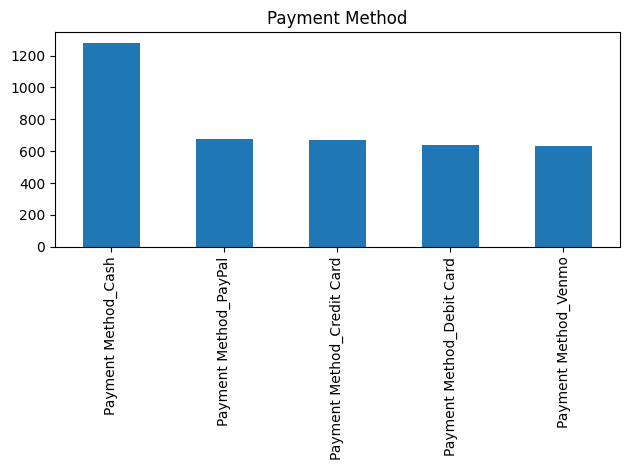

In [400]:
df[['Payment Method_Cash','Payment Method_Credit Card','Payment Method_Debit Card','Payment Method_PayPal','Payment Method_Venmo']].idxmax(axis=1).value_counts().plot(kind='bar')
plt.title('Payment Method')
plt.tight_layout()
plt.show()

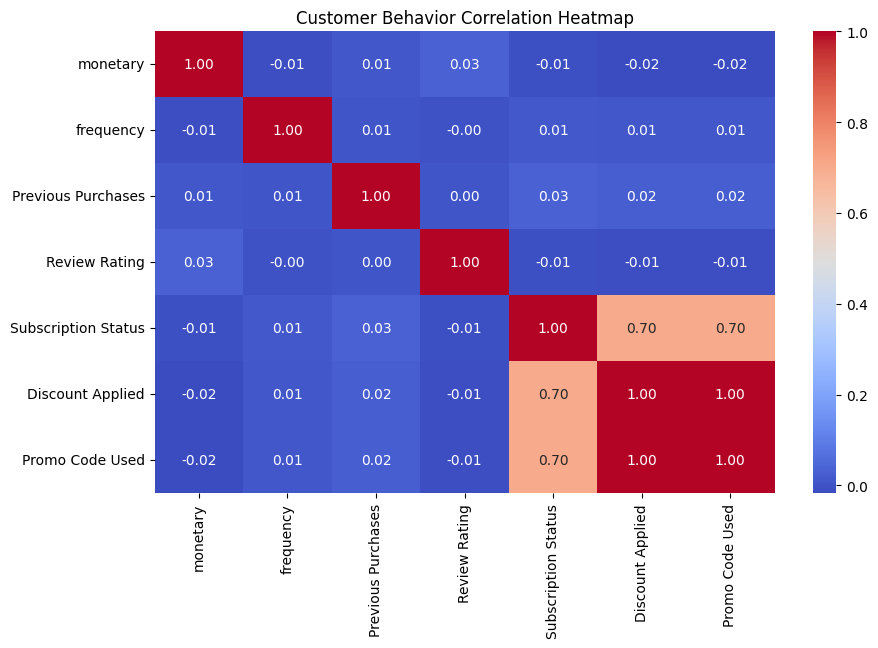

In [401]:
heatmap_cols = ['monetary','frequency','Previous Purchases','Review Rating','Subscription Status','Discount Applied','Promo Code Used',]
plt.figure(figsize=(10,6))

sns.heatmap(df[heatmap_cols].corr(),annot=True,fmt=".2f",cmap='coolwarm')

plt.title("Customer Behavior Correlation Heatmap")
plt.show()

In [402]:
df['spending_power'] = df['monetary'] * df['Previous Purchases']


In [403]:
df['loyalty_score'] = df['frequency'] + df['Previous Purchases']


In [404]:
df['satisfaction_score'] = df['Review Rating'] * df['frequency']


In [405]:
df['deal_sensitivity'] = df['Discount Applied'] + df['Promo Code Used']


In [406]:
df['subscription_value'] = df['Subscription Status'] * df['frequency']


In [407]:
df['purchase_consistency'] = df['frequency'] / (df['Previous Purchases'] + 1)


In [408]:
df['value_per_purchase'] = df['monetary'] / (df['frequency'] + 1)

In [409]:
df['digital_payment_user'] = (df['Payment Method_Credit Card'] +df['Payment Method_PayPal'] +df['Payment Method_Venmo'] +df['Payment Method_Debit Card'])

In [410]:
df['fast_shipping_user'] = ( df['Shipping Type_Express'] +df['Shipping Type_Next Day Air'])

In [411]:
print(df)

           Age  Purchase Amount (USD)  Size  Review Rating  \
0     0.718913              -0.285629     3      -0.907584   
1    -1.648629               0.178852     3      -0.907584   
2     0.390088               0.558882     1      -0.907584   
3    -1.517099               1.276716     2      -0.349027   
4     0.061263              -0.454531     2      -1.466141   
...        ...                    ...   ...            ...   
3895 -0.267563              -1.341267     3       0.628448   
3896  0.521618              -0.454531     3       1.047366   
3897  0.127028              -1.130139     3      -1.186862   
3898 -0.004502               0.727784     1       0.069891   
3899  0.521618               0.896686     2      -0.907584   

      Subscription Status  Discount Applied  Promo Code Used  \
0                       1                 1                1   
1                       1                 1                1   
2                       1                 1                1   

# premiun customers

In [412]:
df['premium_customer'] = ((df['monetary'] > df['monetary'].mean()) & (df['frequency'] > df['frequency'].mean())).astype(int)

# Discount trap customers

In [413]:
df['discount_driven'] = ((df['deal_sensitivity'] > 0)).astype(int)

# Low engagement customer

In [414]:
df['low_engagement'] = (df['loyalty_score'] < df['loyalty_score'].mean()).astype(int)

# ltv = life time value

In [415]:
df['ltv'] = (0.30 * df['monetary'] +0.25 * df['frequency'] +0.20 * df['Previous Purchases'] +0.15 * df['Review Rating'] +0.10 * df['Subscription Status']
)

# Customer Segmentation

In [416]:
df['customer_segment'] = pd.qcut(df['ltv'],3,labels=[0,1,2])

# Heatmaps

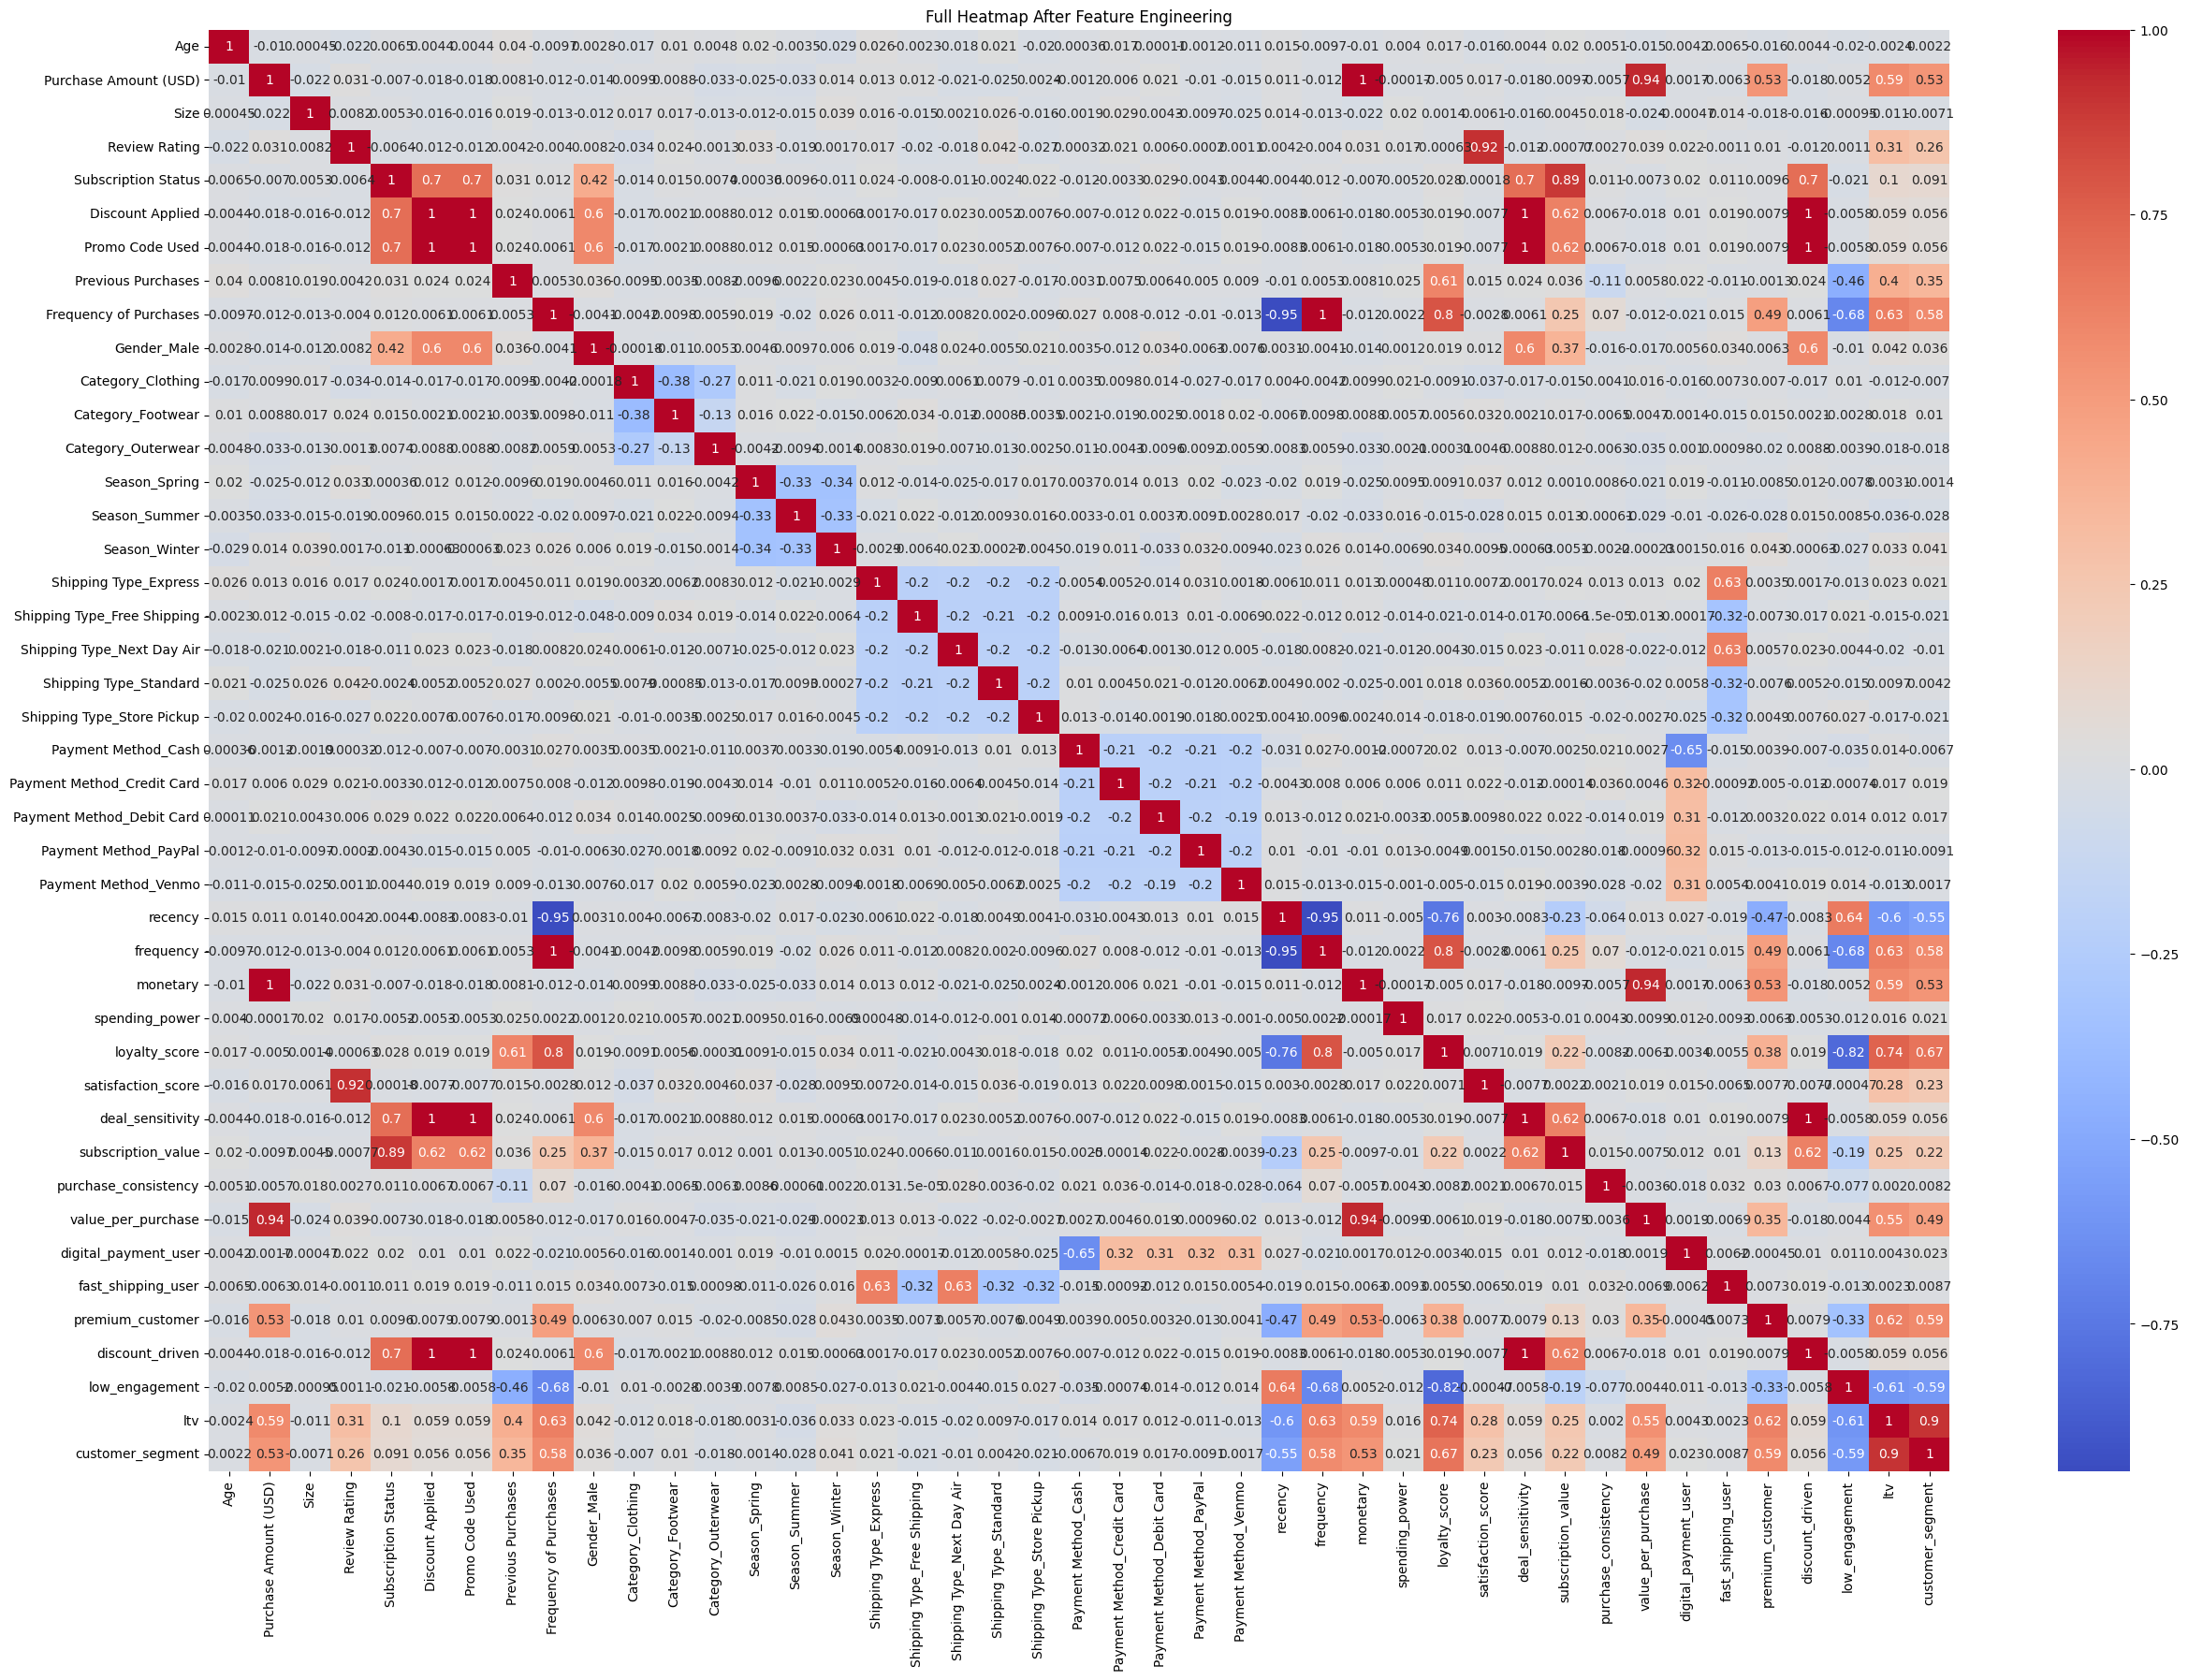

In [417]:
plt.figure(figsize=(30,20))

sns.heatmap(df.corr(),cmap='coolwarm',annot=True)

plt.title("Full Heatmap After Feature Engineering")
plt.show()

In [418]:
print("ltv dropped to prevent data leakage")

ltv dropped to prevent data leakage


In [419]:
df = df.drop(columns=['ltv'])

In [420]:
drop_cols = [
    'Previous Purchases',
    'frequency',
    'Discount Applied',
    'Promo Code Used',
    'Subscription Status',
    'monetary',
    'purchase_consistency',
    'digital_payment_user',
    'fast_shipping_user',
    'Size'
]

df_final = df.drop(columns=drop_cols)

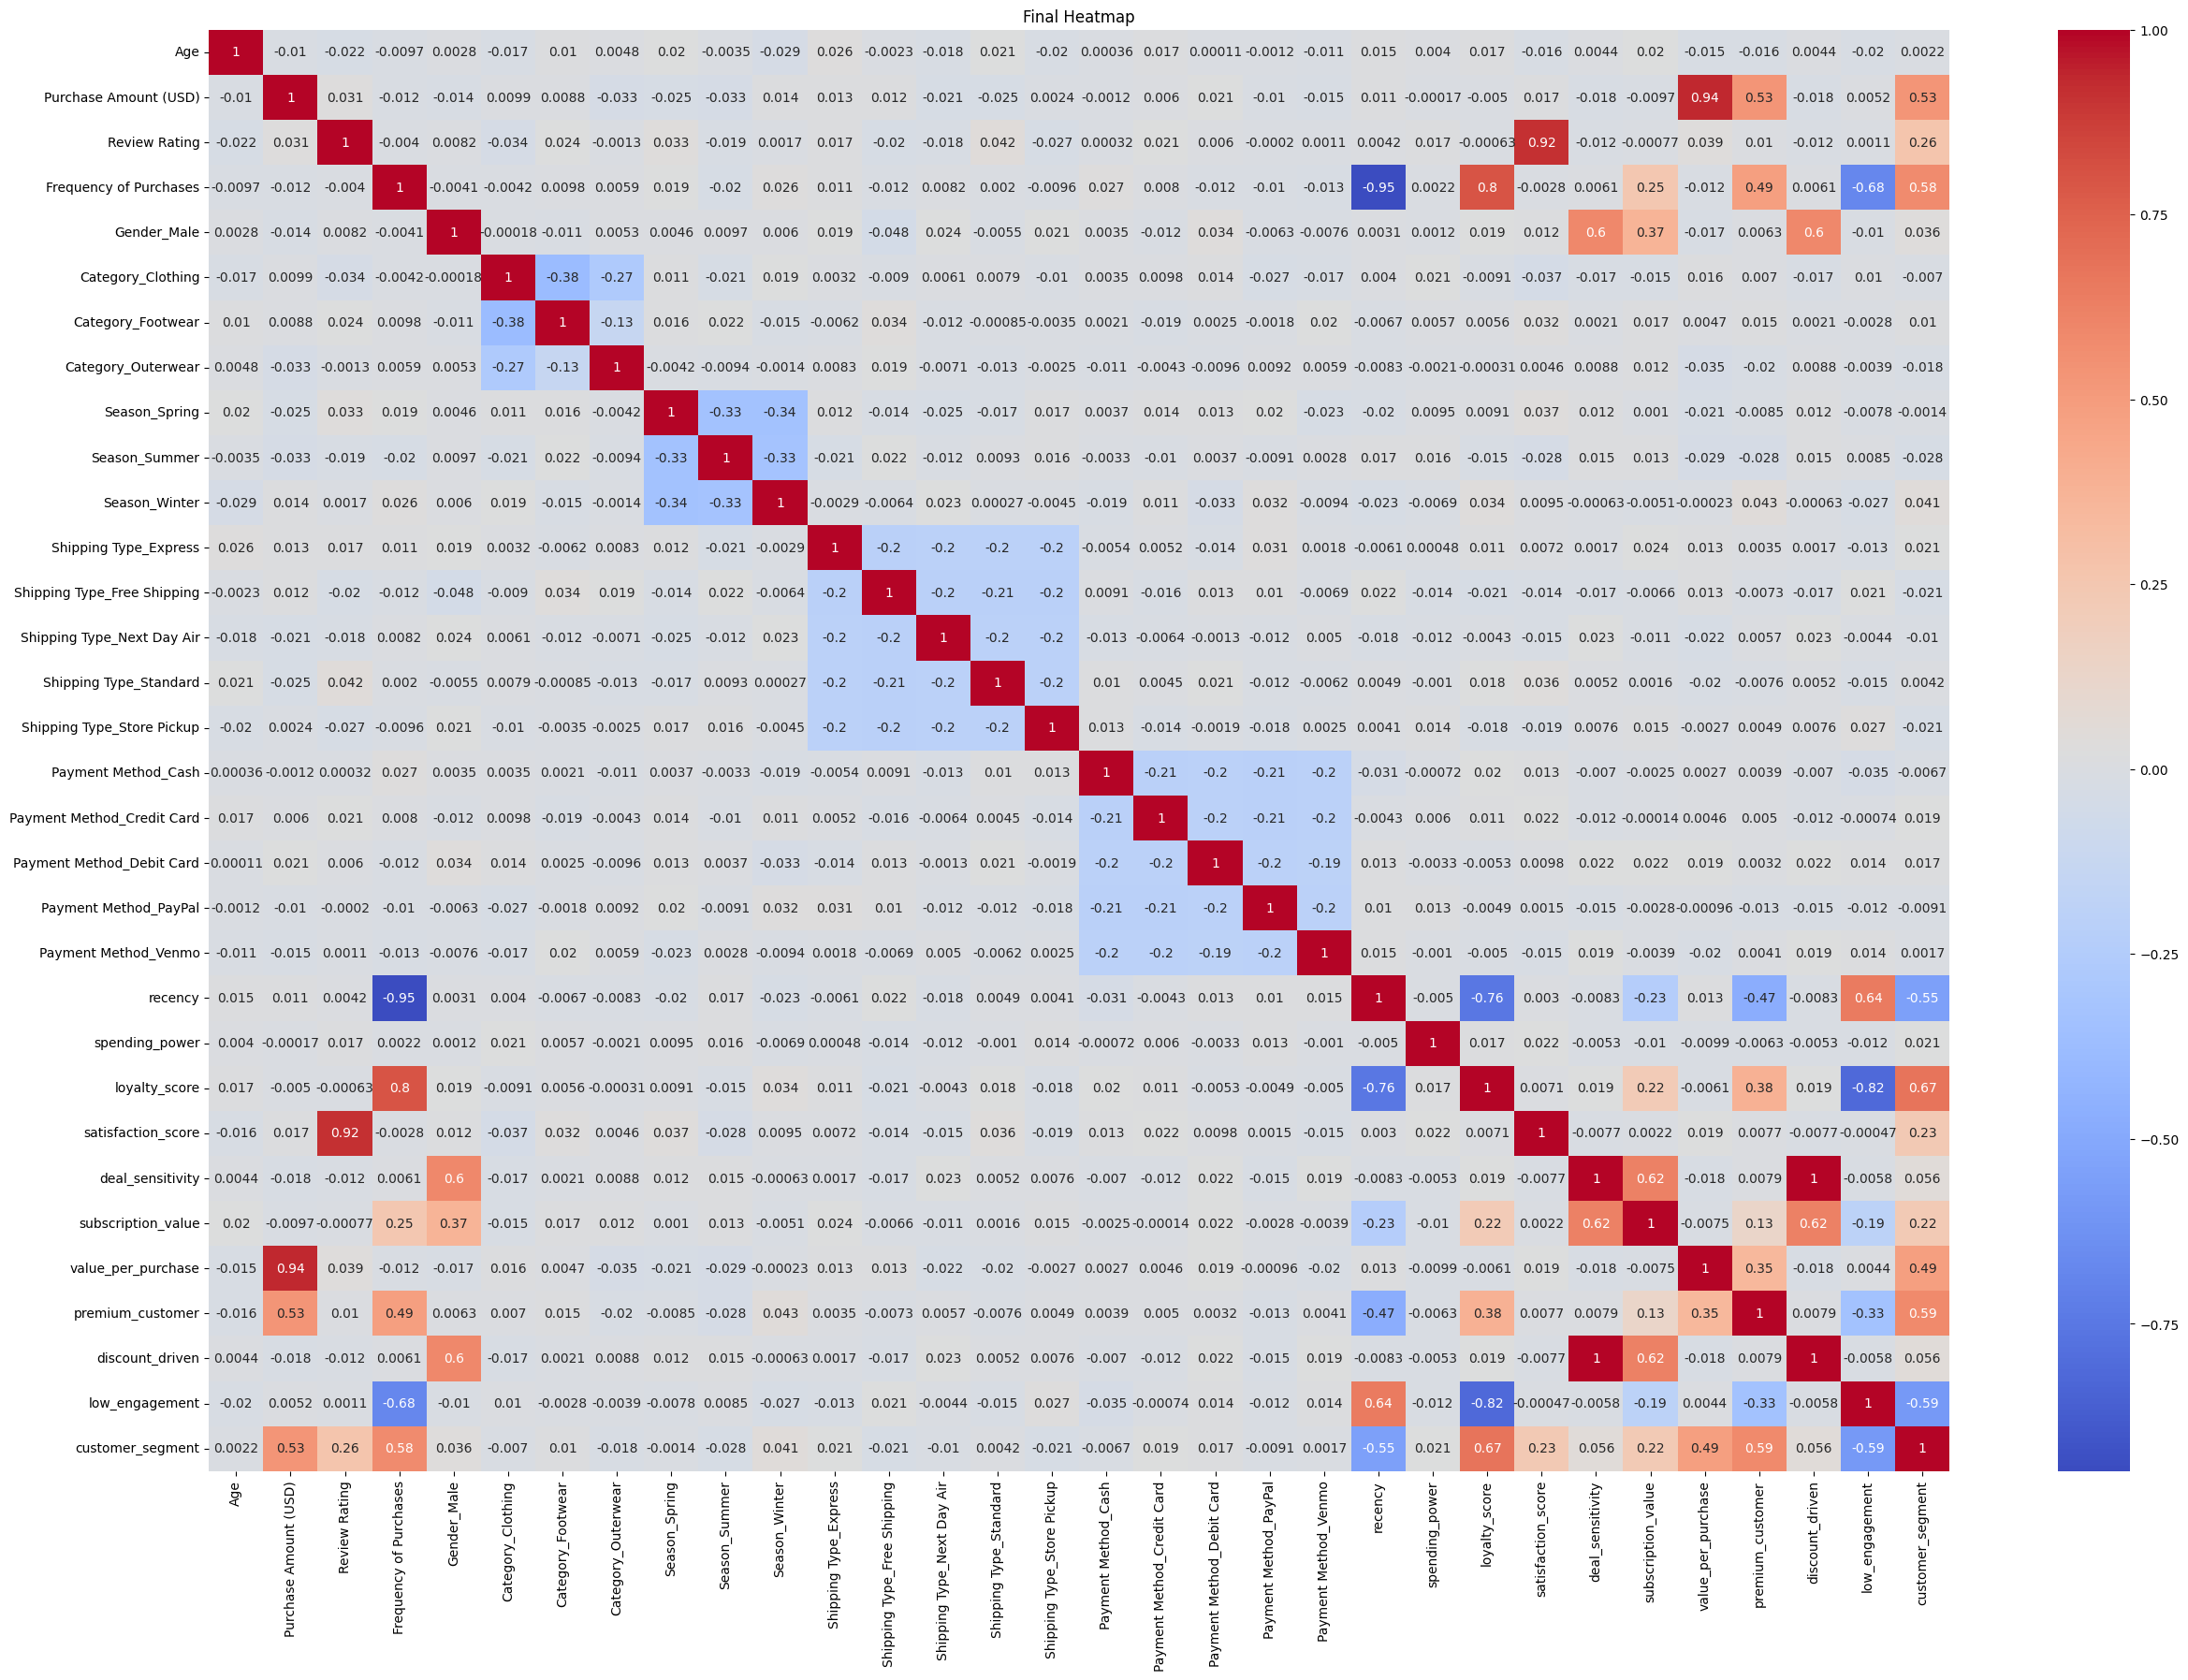

In [421]:
plt.figure(figsize=(30,20))

sns.heatmap(df_final.corr(),cmap='coolwarm',annot=True)

plt.title("Final Heatmap")
plt.show()

In [422]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Age                          3900 non-null   float64 
 1   Purchase Amount (USD)        3900 non-null   float64 
 2   Review Rating                3900 non-null   float64 
 3   Frequency of Purchases       3900 non-null   int64   
 4   Gender_Male                  3900 non-null   bool    
 5   Category_Clothing            3900 non-null   bool    
 6   Category_Footwear            3900 non-null   bool    
 7   Category_Outerwear           3900 non-null   bool    
 8   Season_Spring                3900 non-null   bool    
 9   Season_Summer                3900 non-null   bool    
 10  Season_Winter                3900 non-null   bool    
 11  Shipping Type_Express        3900 non-null   bool    
 12  Shipping Type_Free Shipping  3900 non-null   bool    
 13  Shi

In [423]:
df_final['customer_segment'] = df_final['customer_segment'].astype(int)

In [424]:
x = df_final.drop(['customer_segment'], axis=1)
y = df_final['customer_segment']



In [425]:
print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (3900, 31)
y shape: (3900,)


In [426]:
df_final.to_csv("final_feature_engineered_dataset.csv", index=False)

In [427]:
x.to_csv("x_features.csv", index=False)
y.to_csv("y_target.csv", index=False)